Saving Lenna.png to Lenna.png


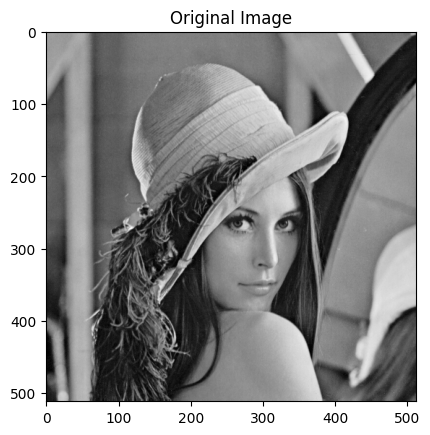

In [ ]:
# STEP 1: Load grayscale image

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]
img = cv2.imread(filename, 0)

plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.show()

rows, cols = img.shape
size = rows * cols

In [ ]:
# STEP 2: Fitness function for PSO

def logistic(x0, r):
    x = np.zeros(size)
    x[0] = x0

    for i in range(1, size):
        x[i] = r * x[i-1] * (1 - x[i-1])
        x[i] = np.clip(x[i], 0, 1)

    return x


def fitness(x0, r):
    x = logistic(x0, r)

    key = np.floor(x * 1e6) % 256
    key = key.astype(np.uint8)

    hist = np.bincount(key, minlength=256)
    prob = hist / np.sum(hist)

    entropy = -np.sum(prob * np.log2(prob + 1e-12))
    return entropy

In [ ]:
# STEP 3: PSO optimization

n_particles = 10
iters = 5

particles = np.random.rand(n_particles, 2)
particles[:,0] = 0.1 + particles[:,0]*0.8   # x0
particles[:,1] = 2.5 + particles[:,1]*1.5   # r

vel = np.zeros_like(particles)

pbest = particles.copy()
pbest_score = np.zeros(n_particles)

gbest = None
gbest_score = -1

w, c1, c2 = 0.7, 1.5, 1.5

for t in range(iters):

    for i in range(n_particles):
        x0, r = particles[i]
        score = fitness(x0, r)

        if score > pbest_score[i]:
            pbest_score[i] = score
            pbest[i] = particles[i]

        if score > gbest_score:
            gbest_score = score
            gbest = particles[i]

    for i in range(n_particles):
        vel[i] = (w*vel[i] +
                  c1*np.random.rand()*(pbest[i]-particles[i]) +
                  c2*np.random.rand()*(gbest-particles[i]))

        particles[i] += vel[i]

x0_opt, r_opt = gbest

print("x0:", x0_opt)
print("r:", r_opt)

x0: 0.18470420471834928
r: 3.953080511862736


In [ ]:
# Chaotic key (NO plaintext dependency)

xk = np.zeros(size)
xk[0] = x0_opt

for i in range(1, size):
    xk[i] = r_opt * xk[i-1] * (1 - xk[i-1])
    xk[i] = np.clip(xk[i], 0, 1)

xk = np.clip(xk, 0, 1)

key = (xk * 255).astype(np.uint8)
key = key.astype(np.uint8)

In [ ]:
# STEP 5: Permutation

flat = img.flatten()

perm_index = np.argsort(xk)   # فقط chaos
inv_perm_index = np.argsort(perm_index)

img_perm = flat[perm_index]

Execution Time: 0.4155724048614502


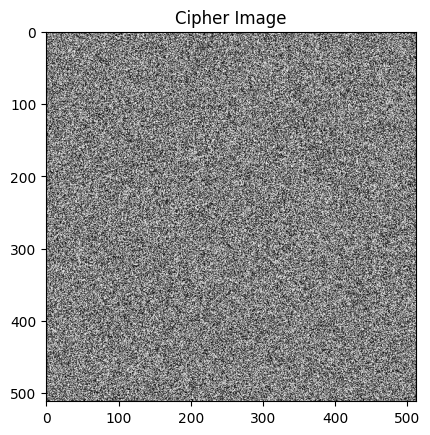

In [ ]:
# STEP 6: Encryption (diffusion with feedback)
import time

start = time.time()
cipher = np.zeros(size, dtype=np.uint8)

cipher[0] = img_perm[0] ^ key[0]

for i in range(1, size):
    cipher[i] = (
        img_perm[i] ^
        key[i] ^
        cipher[i-1] ^
        img_perm[i-1]
    )

end = time.time()

print("Execution Time:", end - start)

cipher_img = cipher.reshape(rows, cols)

plt.imshow(cipher_img, cmap='gray')
plt.title("Cipher Image")
plt.show()

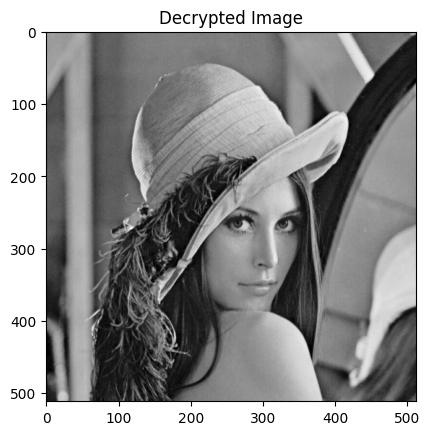

In [ ]:
# STEP 7: Decryption

dec = np.zeros(size, dtype=np.uint8)

dec[0] = cipher[0] ^ key[0]

for i in range(1, size):
    dec[i] = cipher[i] ^ key[i] ^ cipher[i-1] ^ img_perm[i-1]

dec_img = dec[inv_perm_index].reshape(rows, cols)

plt.imshow(dec_img, cmap='gray')
plt.title("Decrypted Image")
plt.show()

In [ ]:
x0_wrong = x0_opt + 0.0001
r_wrong = r_opt

In [ ]:
xk_wrong = np.zeros(size)
xk_wrong[0] = x0_wrong

for i in range(1, size):
    xk_wrong[i] = r_wrong * xk_wrong[i-1] * (1 - xk_wrong[i-1])
    xk_wrong[i] = np.clip(xk_wrong[i], 0, 1)

key_wrong = (xk_wrong * 255).astype(np.uint8)

In [ ]:
dec_wrong = np.zeros(size, dtype=np.uint8)

dec_wrong[0] = cipher[0] ^ key_wrong[0]

for i in range(1, size):
    dec_wrong[i] = cipher[i] ^ key_wrong[i] ^ cipher[i-1] ^ img_perm[i-1]

dec_wrong_img = dec_wrong[inv_perm_index].reshape(rows, cols)

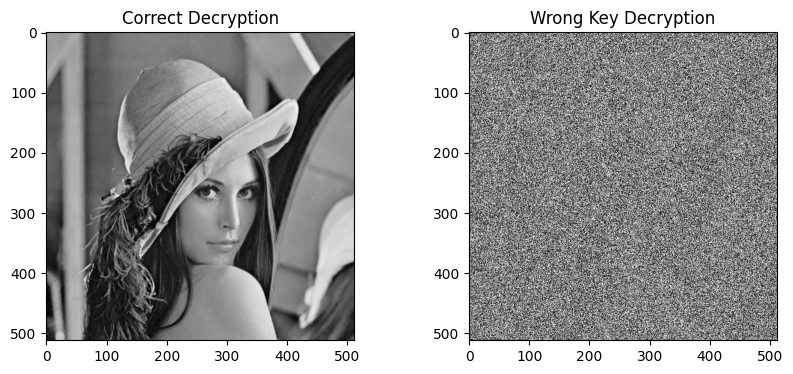

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(dec_img, cmap='gray')
plt.title("Correct Decryption")

plt.subplot(1,2,2)
plt.imshow(dec_wrong_img, cmap='gray')
plt.title("Wrong Key Decryption")

plt.show()